<a href="https://colab.research.google.com/github/mmichellesvv/Antibacterial-Molecule-Screening/blob/main/SheLeads_AIMoL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ACTIVITY**

In [ ]:
!pip install rdkit chembl_webresource_client

In [ ]:
# --------------------------
# 1.Підключення бібліотек
# --------------------------
from chembl_webresource_client.new_client import new_client
import pandas as pd
from rdkit import Chem

# --------------------------
# 2.Завантаження MRSA активності
# --------------------------
activity = new_client.activity
target_id = 'CHEMBL352'  # MRSA

all_data = []
page_size = 100
max_pages = 50  # більше сторінок для більшого датасету (~5000 молекул)

for page in range(max_pages):
    batch = list(
        activity.filter(target_chembl_id=target_id, standard_type='IC50')
        .only(['molecule_chembl_id','canonical_smiles','standard_value'])
        [page*page_size:(page+1)*page_size]
    )
    if not batch:
        break
    all_data.extend(batch)

df_activity = pd.DataFrame(all_data)
df_activity = df_activity.drop_duplicates(subset=['molecule_chembl_id'])

# --------------------------
# 3.Фільтрація некоректних SMILES
# --------------------------
def valid_smiles(smiles):
    try:
        return Chem.MolFromSmiles(smiles) is not None
    except:
        return False

df_activity['valid'] = df_activity['canonical_smiles'].apply(valid_smiles)
df_activity = df_activity[df_activity['valid']].copy()
df_activity.drop(columns=['valid'], inplace=True)

# --------------------------
# 4.Бінаризація активності
# IC50 < 10 μM (10000 nM) → active
# --------------------------
df_activity['active'] = df_activity['standard_value'].apply(lambda x: 1 if x and float(x) < 10000 else 0)
df_activity = df_activity.dropna(subset=['standard_value'])
# --------------------------
# 5.Завантаження токсичності (Tox21)
# --------------------------
# Для MVP можна взяти Tox21 dataset з Kaggle або ChEMBL
# Приклад: https://pubchem.ncbi.nlm.nih.gov/bioassay/743219
# Тут ми імітуємо:
tox_data = {
    'smiles': df_activity['canonical_smiles'].tolist()
}
df_tox = pd.DataFrame(tox_data)

# --------------------------
# 6.Об’єднання даних
# --------------------------
df_final = df_activity[['canonical_smiles','active']].merge(df_tox, left_on='canonical_smiles', right_on='smiles')
df_final.drop(columns=['smiles'], inplace=True)

# --------------------------
# 7.Збереження готового датасету
# --------------------------
df_final.to_csv('activity_dataset.csv', index=False)
print("Готовий датасет для MVP:", df_final.shape)
print(df_final.head())

Готовий датасет для MVP: (552, 2)
                                    canonical_smiles  active
0       Oc1cc(NCCCNC2CCNc3c(Br)cc(Br)cc32)nc2ccccc12       1
1        O=c1cc(NCCCNCc2ccc(Cl)c(Cl)c2)[nH]c2ccccc12       1
2   COc1ccc2c(c1)C(=O)/C(=C/c1ccc([N+](=O)[O-])o1)O2       0
3       O=C(/C=C/c1ccc([N+](=O)[O-])o1)c1cc(Cl)ccc1O       0
4  CC(=O)Oc1ccc(C)cc1C(=O)/C=C/c1ccc([N+](=O)[O-])o1       0


In [ ]:
print(df_final['active'].value_counts())


active
1    382
0    170
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df_final['canonical_smiles']
y = df_final['active']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

def smiles_to_ecfp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits))

# Трансформуємо train/test
X_train_ecfp = np.array([smiles_to_ecfp(s) for s in X_train])
X_test_ecfp = np.array([smiles_to_ecfp(s) for s in X_test])


[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerator
[13:49:44] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
X_train_ecfp

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train_ecfp, y_train)

y_pred_proba = model.predict_proba(X_test_ecfp)[:,1]
y_pred = model.predict(X_test_ecfp)

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))


ROC-AUC: 0.9293353705118411
              precision    recall  f1-score   support

           0       0.85      0.68      0.75        34
           1       0.87      0.95      0.91        77

    accuracy                           0.86       111
   macro avg       0.86      0.81      0.83       111
weighted avg       0.86      0.86      0.86       111



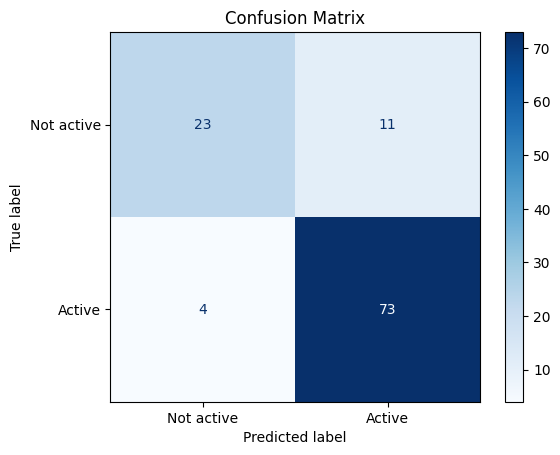

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not active', 'Active'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import joblib

joblib.dump(model, 'mrsa_model.pkl')
joblib.dump({'radius':2,'n_bits':1024}, 'fingerprint_params.pkl')


['fingerprint_params.pkl']

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = []

for train_idx, val_idx in skf.split(X_train_ecfp, y_train):
    X_tr, X_val = X_train_ecfp[train_idx], X_train_ecfp[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model_cv = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    model_cv.fit(X_tr, y_tr)

    y_val_proba = model_cv.predict_proba(X_val)[:,1]
    aucs.append(roc_auc_score(y_val, y_val_proba))

print("CV ROC-AUC mean ± std:", np.mean(aucs), np.std(aucs))

CV ROC-AUC mean ± std: 0.9524373319455288 0.021477429716719516


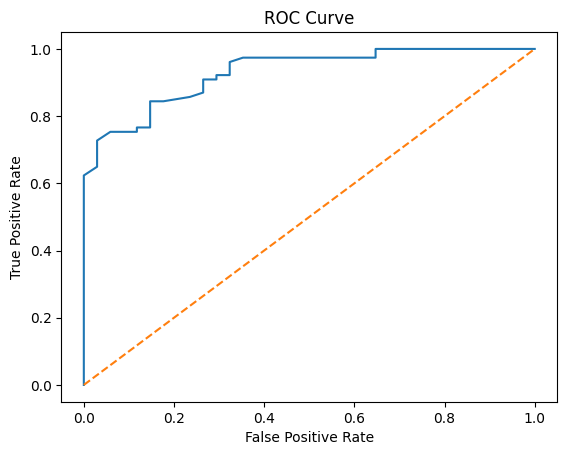

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [ ]:
# import shap

# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_test_ecfp)

# # Візуалізація для одного прикладу
# shap.initjs()
# shap.force_plot(explainer.expected_value, shap_values[0], X_test_ecfp[0])

In [ ]:
df_results = pd.DataFrame({
    'smiles': X_test,
    'prob_active': y_pred_proba
}).sort_values('prob_active', ascending=False)

df_results.head(20)  # топ-20 молекул для тесту/синтезу


,smiles,prob_active
416,CC[C@H](C)[C@H](NC(=O)[C@H](CC1CCCCC1)NC(=O)[C...,1.000
413,NCCC[C@H](N)C(=O)N[C@H](Cc1c[nH]c2ccccc12)C(=O...,1.000
393,COC(=O)[C@H](C)n1sc2ccccc2c1=O,1.000
73,CC(N)C(=O)NC(CCC(=O)O)P(=O)(O)O,0.995
261,[I-].c1ccc(CSc2cc3ccccc3[n+](CCCCCC3CCCCC3)c2)cc1,0.995
259,Fc1cccc(CSc2cc3ccccc3[n+](CCCCCC3CCCCC3)c2)c1....,0.995
290,CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCN(C(c4ccco4)c4...,0.990
296,CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=...,0.990
341,O=C1CSC(c2ccccc2)N1c1ccccc1,0.990
365,O=C(NC[C@H]1CN(c2ccc(N3CC4(COC4)C3)c(F)c2)C(=O...,0.985


# SHAP МОЛЕКУЛ ІЗ ПІДСВІЧЕННЯМ АТОМІВ ЗЄДНАНЬ ЩО СПРИЯЛИ ВІДБОРУ (?)

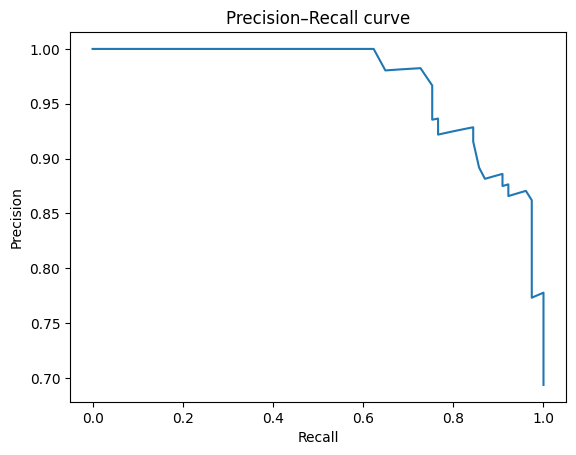

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve")
plt.show()

In [ ]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)  # Додаємо 1e-9, щоб уникнути ділення на нуль
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Оптимальний поріг за F1-score: {optimal_threshold:.3f}")
print(f"Precision при цьому порозі: {precision[optimal_idx]:.3f}")
print(f"Recall при цьому порозі: {recall[optimal_idx]:.3f}")

Оптимальний поріг за F1-score: 0.365
Precision при цьому порозі: 0.862
Recall при цьому порозі: 0.974


In [ ]:
threshold = optimal_threshold  # Використовуємо оптимальний поріг
df_results['pred_active'] = df_results['prob_active'].apply(lambda x: 1 if x >= threshold else 0)
df_results['active'] = y_test

# 7. Виводимо звіт про класифікацію
print(classification_report(df_results['active'], df_results['pred_active']))

              precision    recall  f1-score   support

           0       0.92      0.65      0.76        34
           1       0.86      0.97      0.91        77

    accuracy                           0.87       111
   macro avg       0.89      0.81      0.84       111
weighted avg       0.88      0.87      0.87       111



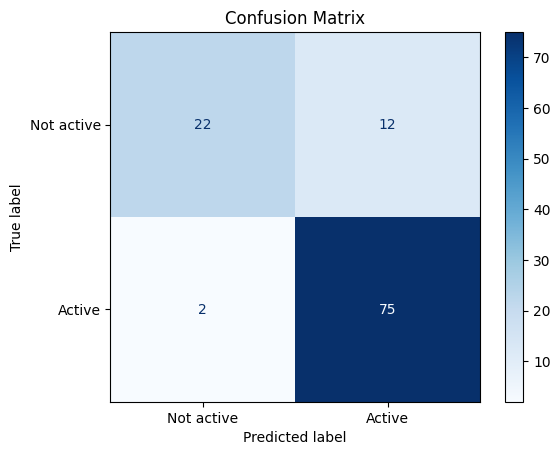

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_true = df_results['active']
y_pred = df_results['pred_active']

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not active', 'Active'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
df_results.sort_values('prob_active').head()

,smiles,prob_active,pred_active,active
449,Brc1ccc(-c2cnc(NCCCCCCCCNc3ncc(-c4ccc(Br)cc4)[...,0.005,0,0
454,Brc1ccc(-c2cnc(NCCCNc3ncc(-c4ccc(Br)cc4)[nH]3)...,0.015,0,0
522,O=C1C=C(c2ccc(O)cc2)[C@]2(O1)O[C@]1(OC(=O)C=C1...,0.025,0,0
431,CCCCCc1nc(N)n(CC(=O)Nc2ccccc2)c1-c1ccccc1Br,0.035,0,0
16,Cc1ccc(O)c(C(=O)/C=C/c2ccc([N+](=O)[O-])o2)c1,0.050,0,0


In [ ]:
df_results.sort_values('prob_active', ascending=False).head(10)

,smiles,prob_active,pred_active,active
416,CC[C@H](C)[C@H](NC(=O)[C@H](CC1CCCCC1)NC(=O)[C...,1.000,1,1
413,NCCC[C@H](N)C(=O)N[C@H](Cc1c[nH]c2ccccc12)C(=O...,1.000,1,1
393,COC(=O)[C@H](C)n1sc2ccccc2c1=O,1.000,1,1
73,CC(N)C(=O)NC(CCC(=O)O)P(=O)(O)O,0.995,1,1
261,[I-].c1ccc(CSc2cc3ccccc3[n+](CCCCCC3CCCCC3)c2)cc1,0.995,1,1
259,Fc1cccc(CSc2cc3ccccc3[n+](CCCCCC3CCCCC3)c2)c1....,0.995,1,1
290,CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCN(C(c4ccco4)c4...,0.990,1,1
296,CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=...,0.990,1,1
341,O=C1CSC(c2ccccc2)N1c1ccccc1,0.990,1,1
365,O=C(NC[C@H]1CN(c2ccc(N3CC4(COC4)C3)c(F)c2)C(=O...,0.985,1,1


In [ ]:
df_results.sort_values('prob_active', ascending=False).tail(10)

,smiles,prob_active,pred_active,active
384,Cc1c(C(=O)Nc2ccccc2)cnn1-c1cc(Cl)ccc1Cl,0.080,0,0
526,O=C1C=C(c2ccc(O)cc2)[C@]2(O1)O[C@@]1(OC(=O)C=C...,0.075,0,0
434,Nc1nc(CC2CC2)c(-c2ccccc2Br)n1CC(=O)Nc1ccccc1,0.065,0,0
3,O=C(/C=C/c1ccc([N+](=O)[O-])o1)c1cc(Cl)ccc1O,0.055,0,0
489,COc1ccc(-c2cc(-c3nc4ccccc4c(=O)[nH]3)nc(N)n2)c...,0.050,0,0
16,Cc1ccc(O)c(C(=O)/C=C/c2ccc([N+](=O)[O-])o2)c1,0.050,0,0
431,CCCCCc1nc(N)n(CC(=O)Nc2ccccc2)c1-c1ccccc1Br,0.035,0,0
522,O=C1C=C(c2ccc(O)cc2)[C@]2(O1)O[C@]1(OC(=O)C=C1...,0.025,0,0
454,Brc1ccc(-c2cnc(NCCCNc3ncc(-c4ccc(Br)cc4)[nH]3)...,0.015,0,0
449,Brc1ccc(-c2cnc(NCCCCCCCCNc3ncc(-c4ccc(Br)cc4)[...,0.005,0,0


In [ ]:
promising_molecules = df_results[df_results['pred_active'] == 1]

promising_molecules

,smiles,prob_active,pred_active,active
416,CC[C@H](C)[C@H](NC(=O)[C@H](CC1CCCCC1)NC(=O)[C...,1.000,1,1
413,NCCC[C@H](N)C(=O)N[C@H](Cc1c[nH]c2ccccc12)C(=O...,1.000,1,1
393,COC(=O)[C@H](C)n1sc2ccccc2c1=O,1.000,1,1
73,CC(N)C(=O)NC(CCC(=O)O)P(=O)(O)O,0.995,1,1
261,[I-].c1ccc(CSc2cc3ccccc3[n+](CCCCCC3CCCCC3)c2)cc1,0.995,1,1
...,...,...,...,...
474,CCCCCc1cccc(C(=O)NCCNC(=O)CCCCCc2cnc(N)[nH]2)c1,0.525,1,1
533,COc1ccc(Nc2ncnc3c2C(c2ccc(OC)cc2)c2c(cc(C)oc2=...,0.525,1,1
1,O=c1cc(NCCCNCc2ccc(Cl)c(Cl)c2)[nH]c2ccccc12,0.455,1,1
176,CCCCCc1c(C/C=C(\C)CCC=C(C)C)c(O)cc(O)c1OC(C)=O,0.365,1,1


In [ ]:
promising_molecules.to_csv("p_m_activity.csv", index=False)

In [ ]:
import joblib
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem

joblib.dump(model, "mrsa_model.pkl")

def predict_smiles(smiles, model, threshold=0.6, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)).reshape(1, -1)
    proba = model.predict_proba(fp)[0, 1]
    predicted_class = 1 if proba >= threshold else 0
    return proba, predicted_class

In [ ]:
df_screen = df_final.copy()
results = df_screen['canonical_smiles'].apply(lambda s: predict_smiles(s, model, optimal_threshold))

# Розпаковуємо результати у два стовпці: prob_active і pred_active
df_screen['prob_active'] = results.apply(lambda x: x[0])
df_screen['pred_active'] = results.apply(lambda x: x[1])

[14:18:47] DEPRECATION WARNING: please use MorganGenerator
[14:18:48] DEPRECATION WARNING: please use MorganGenerator
[14:18:48] DEPRECATION WARNING: please use MorganGenerator
[14:18:48] DEPRECATION WARNING: please use MorganGenerator
[14:18:48] DEPRECATION WARNING: please use MorganGenerator
[14:18:48] DEPRECATION WARNING: please use MorganGenerator
[14:18:48] DEPRECATION WARNING: please use MorganGenerator
[14:18:48] DEPRECATION WARNING: please use MorganGenerator
[14:18:48] DEPRECATION WARNING: please use MorganGenerator
[14:18:48] DEPRECATION WARNING: please use MorganGenerator
[14:18:48] DEPRECATION WARNING: please use MorganGenerator
[14:18:48] DEPRECATION WARNING: please use MorganGenerator
[14:18:48] DEPRECATION WARNING: please use MorganGenerator
[14:18:48] DEPRECATION WARNING: please use MorganGenerator
[14:18:49] DEPRECATION WARNING: please use MorganGenerator
[14:18:49] DEPRECATION WARNING: please use MorganGenerator
[14:18:49] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
df_screen[['canonical_smiles', 'prob_active', 'pred_active', 'active']].reset_index()

,index,canonical_smiles,prob_active,pred_active,active
0,0,Oc1cc(NCCCNC2CCNc3c(Br)cc(Br)cc32)nc2ccccc12,0.870,1,1
1,1,O=c1cc(NCCCNCc2ccc(Cl)c(Cl)c2)[nH]c2ccccc12,0.455,1,1
2,2,COc1ccc2c(c1)C(=O)/C(=C/c1ccc([N+](=O)[O-])o1)O2,0.020,0,0
3,3,O=C(/C=C/c1ccc([N+](=O)[O-])o1)c1cc(Cl)ccc1O,0.055,0,0
4,4,CC(=O)Oc1ccc(C)cc1C(=O)/C=C/c1ccc([N+](=O)[O-])o1,0.010,0,0
...,...,...,...,...,...
547,547,CC(C)(C)OC(=O)NCCn1cc(-c2nc(-c3c[nH]c4ncccc34)...,0.955,1,1
548,548,COCCn1cc(-c2csc(-c3cn(C(=O)OC(C)(C)C)c4ccccc34...,0.980,1,1
549,549,C/C1=C/[C@@H](OC(=O)CCC(=O)O)/C=C(/C=O)[C@H]2C...,0.880,1,1
550,550,CC(C)c1cc(=O)c2c(cc(O)c3c(=O)c4c(O)c(Br)ccc4c(...,0.910,1,1


https://chem.echa.europa.eu/substance-search?searchText=CC(%3DO)NC1%3DCC%3DCC%3DC1 - SEARCH BY SMILES ~~~

За доступними даними, ацетанілід (Acetanilide) не згадується як препарат з активністю проти метицилін-резистентного золотистого стафілокока (MRSA). У літературі та сучасних дослідженнях акцент робиться на таких антибіотиках, як ванкоміцин, тейкопланін, лінезолід, даптоміцин, цефтаролін, а також нові експериментальні препарати (наприклад, пре-метиленоміцин C-лактон), які демонструють високу ефективність проти MRSA.

Якщо вам потрібна інформація про конкретні препарати або альтернативні методи лікування MRSA, дайте знати!

In [ ]:
smiles = "CC(=O)NC1=CC=CC=C1" # Acetanilide (not active)
smiles_ = "C[C@H]1[C@H]([C@@](C[C@@H](O1)O[C@@H]2[C@H]([C@@H]([C@H](O[C@H]2OC3=C4C=C5C=C3OC6=C(C=C(C=C6)[C@H]([C@H](C(=O)N[C@H](C(=O)N[C@H]5C(=O)N[C@@H]7C8=CC(=C(C=C8)O)C9=C(C=C(C=C9O)O)[C@H](NC(=O)[C@H]([C@@H](C1=CC(=C(O4)C=C1)Cl)O)NC7=O)C(=O)O)CC(=O)N)NC(=O)[C@@H](CC(C)C)NC)O)Cl)CO)O)O)(C)N)O.Cl" # Vancomycin Hydrochloride (active)

In [ ]:
smiles = smiles_ # Приклад SMILES
proba, predicted_class = predict_smiles(smiles, model, threshold=optimal_threshold)
print(f"Ймовірність активності: {proba:.3f}, Передбачений клас: {predicted_class}")

Ймовірність активності: 0.970, Передбачений клас: 1


[14:19:39] DEPRECATION WARNING: please use MorganGenerator


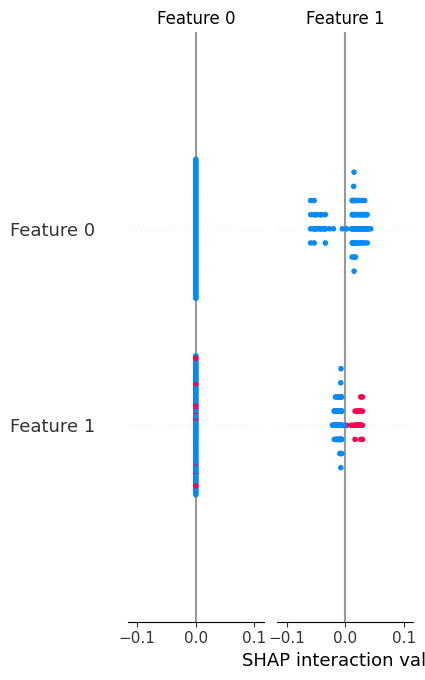

In [ ]:
import shap


explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_ecfp)

shap.summary_plot(shap_values, X_test_ecfp, show=True)

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib

app = FastAPI()
model = joblib.load("mrsa_model.pkl")

class SmilesInput(BaseModel):
    smiles: str

@app.post("/predict")
def predict(data: SmilesInput):
    proba = predict_smiles(data.smiles, model)
    if proba is None:
        return {"error": "Invalid SMILES"}
    return {
        "prob_active": float(proba),
        "class": int(proba > 0.4)
    }

# **TOXITY**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("epicskills/tox21-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tox21-dataset' dataset.
Path to dataset files: /kaggle/input/tox21-dataset


In [ ]:
import os

df_tox = pd.read_csv("/kaggle/input/tox21-dataset/"+os.listdir(path)[0])

df_tox.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem

# Вибираємо NR-AR
df_tox = df_tox[['smiles','NR-AR']].dropna()
df_tox = df_tox[df_tox['NR-AR'].isin([0,1])]  # лишаємо лише бінарні значення
print("Tox21 NR-AR dataset:")

Tox21 NR-AR dataset:


In [ ]:
df_tox.head()

,smiles,NR-AR
0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,0.0
1,CCN1C(=O)NC(c2ccccc2)C1=O,0.0
3,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,0.0
4,CC(O)(P(=O)(O)O)P(=O)(O)O,0.0
5,CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C,0.0


In [ ]:
df_tox.shape

(7265, 2)

In [ ]:
def valid_smiles(smiles):
    try:
        return Chem.MolFromSmiles(smiles) is not None
    except:
        return False

df_tox['valid'] = df_tox['smiles'].apply(valid_smiles)
df_tox = df_tox[df_tox['valid']].copy()
df_tox.drop(columns=['valid'], inplace=True)
print("After filtering invalid SMILES:")

[14:20:03] WARNING: not removing hydrogen atom without neighbors
[14:20:04] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:20:04] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:20:04] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:20:04] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:20:04] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:20:05] Explicit valence for atom # 16 Al, 6, is greater than permitted


After filtering invalid SMILES:


[14:20:05] Explicit valence for atom # 20 Al, 6, is greater than permitted


In [ ]:
df_tox.head()

,smiles,NR-AR
0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,0.0
1,CCN1C(=O)NC(c2ccccc2)C1=O,0.0
3,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,0.0
4,CC(O)(P(=O)(O)O)P(=O)(O)O,0.0
5,CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C,0.0


In [ ]:
df_tox.shape

(7258, 2)

In [ ]:
df_tox.to_csv('toxity_dataset.csv', index=False)

In [ ]:
def smiles_to_ecfp(smiles, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(smiles)
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits))

X = np.array([smiles_to_ecfp(s) for s in df_tox['smiles']])
y = df_tox['NR-AR'].values

Streaming output truncated to the last 5000 lines.
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:20:07] DEPRECATION WARNING: please use MorganGenerator
[14:2

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

model_tox = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=42
)
model_tox.fit(X_train, y_train)

y_pred_proba = model_tox.predict_proba(X_test)[:,1]
y_pred = model_tox.predict(X_test)

print("Tox NR-AR ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

Tox NR-AR ROC-AUC: 0.7256614063587841
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      1390
         1.0       0.80      0.39      0.52        62

    accuracy                           0.97      1452
   macro avg       0.89      0.69      0.75      1452
weighted avg       0.97      0.97      0.96      1452



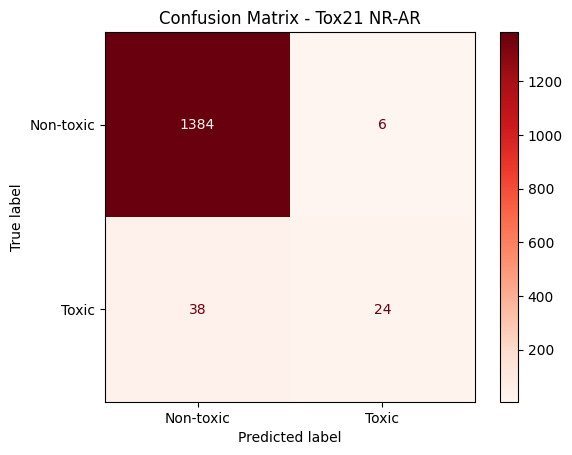

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-toxic','Toxic'])
disp.plot(cmap=plt.cm.Reds)
plt.title("Confusion Matrix - Tox21 NR-AR")
plt.show()

In [ ]:
# import shap

# explainer = shap.TreeExplainer(model_tox)
# shap_values = explainer.shap_values(X_test)

# shap.initjs()
# shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_test[0])

Це дозволяє бачити які частини молекули впливають на токсичність.

In [ ]:
df_tox_results = pd.DataFrame({
    'smiles': df_tox['smiles'].iloc[X_test.shape[0]*-1:],  # ті, що в тесті
    'prob_toxic': y_pred_proba,
    'pred_toxic': y_pred,
    'toxic':y_test
})

In [ ]:
df_tox_results.sort_values('prob_toxic').head()

,smiles,prob_toxic,pred_toxic,toxic
6677,CN1CCN(C(c2ccccc2)c2ccccc2)CC1,0.000134,0,0.0
6863,O=C(O)Cc1cc(I)c(Oc2cc(I)c(O)c(I)c2)c(I)c1,0.000186,0,0.0
6485,CC(CC(=O)O)CC(C)(C)C,0.000193,0,0.0
7008,O=C1c2ccccc2C(=O)N1CCl,0.000207,0,0.0
6818,COC(=O)NCCC[Si](OC)(OC)OC,0.000256,0,0.0


In [ ]:
df_tox_results.sort_values('prob_toxic', ascending=False).head(10)

,smiles,prob_toxic,pred_toxic,toxic
7343,OC[C@H]1O[C@@H](O)[C@H](O)[C@@H](O)[C@@H]1O[C@...,0.997064,1,1.0
7776,CS(=O)(=O)c1ccc(Cl)cc1,0.994091,1,1.0
6313,CCc1ccc(CC)cc1,0.993986,1,1.0
7611,Cc1cccc(Cl)c1,0.991610,1,1.0
6538,Cc1ccc(NC(N)=O)cc1,0.991403,1,1.0
6487,CC(=O)c1ccc2ccccc2c1,0.988860,1,1.0
7157,CC1(C(=O)Nc2ccc(O)c(Cl)c2Cl)CCCCC1,0.985214,1,1.0
7099,CCc1ccc(CCOc2ccc(CC3SC(=O)NC3=O)cc2)nc1,0.979288,1,1.0
6491,O=C/C=C/c1ccco1,0.976673,1,1.0
7747,O=CCCl,0.966676,1,1.0


In [ ]:
df_tox_results.sort_values('prob_toxic', ascending=False).tail(10)

,smiles,prob_toxic,pred_toxic,toxic
7695,CCCCCCCCCC,0.000372,0,0.0
7667,CC(C)[C@@H]1CC[C@@H](C)C[C@H]1O,0.000355,0,1.0
6579,Cc1ccc2oc(CN(Cc3ccccc3)C(=O)Nc3c(F)cc(F)cc3F)c...,0.000355,0,0.0
6812,CC(C)C[C@@H](N)C(=O)O,0.000342,0,0.0
6864,CCc1cc(Cc2cc(CC)c(N)c(CC)c2)cc(CC)c1N,0.000319,0,0.0
6818,COC(=O)NCCC[Si](OC)(OC)OC,0.000256,0,0.0
7008,O=C1c2ccccc2C(=O)N1CCl,0.000207,0,0.0
6485,CC(CC(=O)O)CC(C)(C)C,0.000193,0,0.0
6863,O=C(O)Cc1cc(I)c(Oc2cc(I)c(O)c(I)c2)c(I)c1,0.000186,0,0.0
6677,CN1CCN(C(c2ccccc2)c2ccccc2)CC1,0.000134,0,0.0


In [ ]:
promising_molecules = df_tox_results[df_tox_results['pred_toxic'] == 0]

promising_molecules

,smiles,prob_toxic,pred_toxic,toxic
6271,Nc1c(Cl)c(Cl)nc(C(=O)O)c1Cl,0.031854,0,0.0
6272,C=C(C)C(=O)OCCO,0.013277,0,0.0
6273,C=CC(=O)OCCO,0.009571,0,0.0
6274,O=P(c1ccccc1)(c1ccccc1)c1ccccc1,0.001935,0,0.0
6275,CCOP(=S)(OCC)SCSc1ccc(Cl)cc1,0.013166,0,0.0
...,...,...,...,...
7825,CCCNCC(O)COc1ccccc1C(=O)CCc1ccccc1,0.003164,0,0.0
7827,CC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(...,0.070727,0,0.0
7828,C[C@]12CC[C@H]3[C@@H](CCC4=CC(=O)CC[C@@]43C)[C...,0.003320,0,0.0
7829,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...,0.004472,0,0.0


In [ ]:
promising_molecules.to_csv("p_m_toxity.csv", index=False)

# **RESISTANCY**

In [ ]:
# --------------------------
# 1.Підключення бібліотек
# --------------------------
from chembl_webresource_client.new_client import new_client
import pandas as pd
from rdkit import Chem

# --------------------------
# 2.Завантаження активності проти MRSA для резистентності
# --------------------------
activity = new_client.activity
target_id = 'CHEMBL352'  # MRSA, як приклад

all_data = []
page_size = 100
max_pages = 50  # ~5000 молекул

for page in range(max_pages):
    batch = list(
        activity.filter(target_chembl_id=target_id) \
        .only(['molecule_chembl_id','canonical_smiles','standard_value','standard_type']) \
        [page*page_size:(page+1)*page_size]
    )
    if not batch:
        break
    all_data.extend(batch)

df_res = pd.DataFrame(all_data)
df_res = df_res.drop_duplicates(subset=['molecule_chembl_id'])
print("Завантажено молекул для резистентності:", df_res.shape)

# --------------------------
# 3.Фільтрація некоректних SMILES
# --------------------------
def valid_smiles(smiles):
    try:
        return Chem.MolFromSmiles(smiles) is not None
    except:
        return False

df_res['valid'] = df_res['canonical_smiles'].apply(valid_smiles)
df_res = df_res[df_res['valid']].copy()
df_res.drop(columns=['valid'], inplace=True)
print("Після фільтрації некоректних SMILES:", df_res.shape)

# --------------------------
# 4.Бінаризація резистентності
# IC50 < 10 μM → чутливий (0), ≥10 μM → резистентний (1)
# --------------------------
def binarize_resistance(x, threshold=10000):
    try:
        return 1 if float(x) >= threshold else 0
    except:
        return 0  # якщо немає даних, вважається чутливим

df_res['resistant'] = df_res['standard_value'].apply(binarize_resistance)

# --------------------------
# 5.Збереження готового датасету
# --------------------------
df_res_final = df_res[['canonical_smiles','resistant']]
df_res_final.to_csv('resistance_dataset.csv', index=False)
print("Готовий датасет для моделі резистентності:", df_res_final.shape)
print(df_res_final.head())

Завантажено молекул для резистентності: (555, 6)
Після фільтрації некоректних SMILES: (554, 6)
Готовий датасет для моделі резистентності: (554, 2)
                                     canonical_smiles  resistant
0   NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...          0
1   CC[C@H]1OC(=O)[C@H](C)[C@H]2OC3(CCN(C(=O)c4ccc...          0
4   CC[C@H]1OC(=O)[C@H](C)[C@H]2OC3(CCN(C(=O)c4cnc...          0
6   CN1Cc2csc3c(C(=O)O)c(=O)c4cc(F)c(N5CCOC(CF)C5)...          0
11  CC[C@H]1OC(=O)[C@H](C)C(=O)[C@H](C)[C@@H](O[C@...          0


In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem

# Приклад CSV з резистентністю: smiles, resistant (0=sensitive, 1=resistant)
df_res = df_res_final
# Фільтруємо некоректні SMILES
def valid_smiles(smiles):
    try:
        return Chem.MolFromSmiles(smiles) is not None
    except:
        return False

df_res['valid'] = df_res['canonical_smiles'].apply(valid_smiles)
df_res = df_res[df_res['valid']].copy()
df_res.drop(columns=['valid'], inplace=True)
print("Valid molecules for resistance prediction:", df_res.shape)

Valid molecules for resistance prediction: (554, 2)


In [ ]:
def smiles_to_ecfp(smiles, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(smiles)
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits))

X_res = np.array([smiles_to_ecfp(s) for s in df_res['canonical_smiles']])
y_res = df_res['resistant'].values

[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerator
[14:20:17] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

model_res = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=42
)
model_res.fit(X_train, y_train)

y_pred_proba = model_res.predict_proba(X_test)[:,1]
y_pred = model_res.predict(X_test)

print("Resistance ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

Resistance ROC-AUC: 0.9088785046728972
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       107
           1       0.50      0.25      0.33         4

    accuracy                           0.96       111
   macro avg       0.74      0.62      0.66       111
weighted avg       0.96      0.96      0.96       111



In [ ]:
# import shap

# explainer = shap.TreeExplainer(model_res)
# shap_values = explainer.shap_values(X_test)

# shap.initjs()
# shap.force_plot(explainer.expected_value[1], shap_values[1][0], X_test[0])

In [ ]:
df_res_results = pd.DataFrame({
    'smiles': df_res['canonical_smiles'].iloc[X_test.shape[0]*-1:],  # ті, що в тесті
    'prob_resistant': y_pred_proba,
    'pred_resistant': y_pred,
    'resistant': y_test
})

In [ ]:
df_res_results.sort_values('prob_resistant').head()

,smiles,prob_resistant,pred_resistant,resistant
1078,COc1c(N2CCNCC2)c(F)cc2c(=O)c(C(=O)O)cn(C3CC3)c12,0.000050,0,0
900,C[C@@H](O)[C@H]1C(=O)N2C(C(=O)[O-])=C(CN3C(=O)...,0.000056,0,0
1000,CCCC(=O)OC1C(C)OC(OC2C(C)OC(O[C@H]3[C@@H](CC=O...,0.000066,0,0
1023,CCCc1ccc(S(=O)(=O)Nc2ccc(Cl)c([N+](=O)[O-])c2)cc1,0.000071,0,0
969,CCN1CCN(c2cc3c(cc2F)c(=O)c(C(=O)O)cn3CC)CC1,0.000074,0,0


In [ ]:
df_res_results.sort_values('prob_resistant', ascending=False).head(10)

,smiles,prob_resistant,pred_resistant,resistant
987,NC1CCN(c2cc3c(cc2F)c(=O)c(C(=O)O)cn3C2CCC2)C1,0.921253,1,0
991,CCN1CCN(C(=O)NC(C(=O)N[C@@H]2C(=O)N3C(C(=O)O)=...,0.797185,1,1
1001,COc1ccc(-c2ccc(N3CC(CNC(C)=O)OC3=O)cc2)ccc1=O,0.102226,0,0
930,CCNCC1CCN(c2cc3c(cc2F)c(=O)c(C(=O)O)cn3-c2ccc(...,0.045815,0,1
934,C[C@@H](O)[C@H]1C(=O)N2C(C(=O)[O-])=C(CSC(=S)N...,0.031394,0,0
940,Oc1c2c(nn1-c1ccccc1)CCS2,0.029918,0,0
877,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,0.028059,0,0
931,CC1CN(c2cc3c(cc2F)c(=O)c(C(=O)O)cn3C(C)C)CC(C)N1,0.027447,0,1
956,C=CCc1cc(Cc2cnc(N)nc2N)ccc1O,0.025870,0,0
980,N[C@@H](C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(Cl)CS[...,0.023933,0,0


In [ ]:
df_res_results.sort_values('prob_resistant', ascending=False).tail(10)

,smiles,prob_resistant,pred_resistant,resistant
947,N[C@@H](C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(C(F)(F...,0.000110,0,0
1021,C=C(CCCCCCCC)C(=O)Nc1ccc(Cl)c([N+](=O)[O-])c1,0.000091,0,0
929,CCCCN1CCN(c2cc3c(cc2F)c(=O)c(C(=O)O)cn3-c2ccc(...,0.000086,0,0
985,Nc1cc(SC2=C(C(=O)O)N3C(=O)C(NC(=O)/C(=N\O)c4cs...,0.000079,0,0
1057,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C([n+...,0.000077,0,0
969,CCN1CCN(c2cc3c(cc2F)c(=O)c(C(=O)O)cn3CC)CC1,0.000074,0,0
1023,CCCc1ccc(S(=O)(=O)Nc2ccc(Cl)c([N+](=O)[O-])c2)cc1,0.000071,0,0
1000,CCCC(=O)OC1C(C)OC(OC2C(C)OC(O[C@H]3[C@@H](CC=O...,0.000066,0,0
900,C[C@@H](O)[C@H]1C(=O)N2C(C(=O)[O-])=C(CN3C(=O)...,0.000056,0,0
1078,COc1c(N2CCNCC2)c(F)cc2c(=O)c(C(=O)O)cn(C3CC3)c12,0.000050,0,0


In [ ]:
promising_molecules = df_res_results[df_res_results['pred_resistant'] == 0]

promising_molecules

,smiles,prob_resistant,pred_resistant,resistant
870,O=C(O)c1cn(C2C[C@@H]2F)c2c(Cl)c(N3C[C@H]4CCCN[...,0.011798,0,0
871,COc1cccc(C(=O)Nc2cc(C(=O)Nc3cc(C(=O)Nc4cc(C(=O...,0.000208,0,0
873,CC(C)CCn1cc(NC(=O)c2cc(NC(=O)c3cc([N+](=O)[O-]...,0.000824,0,0
875,Cc1sc(NC(=O)c2cc(NC=O)cn2C)cc1C(=O)Nc1cc(C(=O)...,0.000155,0,0
877,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,0.028059,0,0
...,...,...,...,...
1064,CCNCC1CCN(c2c(F)cc3c(=O)c(C(=O)O)cn(CC)c3c2F)C1,0.015176,0,0
1066,CN(C)CC1CCN(c2c(F)cc3c(=O)c(C(=O)O)cn(C4CC4)c3...,0.000209,0,0
1074,NCCCNCc1ccc(Cn2c(C3CCNCC3)nc3cc(Cl)c(Cl)cc32)cc1,0.003661,0,0
1076,NC1CCN(c2cc3c(cc2F)c(=O)c(C(=O)O)cn3C2CC2)C1,0.005664,0,0


In [ ]:
promising_molecules.to_csv("p_m_resistance.csv", index=False)

# **SCORE**

In [ ]:
# --------------------------
# 1.Підключення бібліотек
# --------------------------
import pandas as pd
import numpy as np

# --------------------------
# 2.Завантаження проміжних результатів
# --------------------------
df_activity = pd.read_csv("p_m_activity.csv")      # smiles, prob_active, pred_active, active
df_tox = pd.read_csv("p_m_toxity.csv")           # smiles, prob_toxic, pred_toxic, toxic
df_res = pd.read_csv("p_m_resistance.csv")       # smiles, prob_resistant, pred_resistant, resistant

# --------------------------
# 3.Об'єднання трьох моделей по SMILES
# --------------------------
df_final = df_activity.merge(df_tox, on='smiles', how='outer') \
                      .merge(df_res, on='smiles', how='outer')

# Заповнюємо NaN (якщо молекула не пройшла певну модель) нулями
for col in ['prob_active', 'pred_active', 'active',
            'prob_toxic', 'pred_toxic', 'toxic',
            'prob_resistant', 'pred_resistant', 'resistant']:
    if col in df_final.columns:
        df_final[col] = df_final[col].fillna(0)

# --------------------------
# 4.Обчислення фінального score
# --------------------------
# Логіка: активність ↑, токсичність ↓, резистентність ↓
df_final['final_score'] = df_final['prob_active'] * \
                          (1 - df_final['prob_toxic']) * \
                          (1 - df_final['prob_resistant'])

# --------------------------
# 5.Сортування за фінальним score
# --------------------------
df_final = df_final.sort_values('final_score', ascending=False)

# --------------------------
# 6.Збереження фінального MVP датасету
# --------------------------
df_final.to_csv("final_promising_molecules.csv", index=False)

# --------------------------
# 7.Попередній перегляд топ-20 молекул
# --------------------------
df_final[['smiles','prob_active','prob_toxic','prob_resistant','final_score']].head(20)

,smiles,prob_active,prob_toxic,prob_resistant,final_score
1247,NCCC[C@H](N)C(=O)N[C@H](Cc1c[nH]c2ccccc12)C(=O...,1.000,0.0,0.0,1.000
717,CC[C@H](C)[C@H](NC(=O)[C@H](CC1CCCCC1)NC(=O)[C...,1.000,0.0,0.0,1.000
859,COC(=O)[C@H](C)n1sc2ccccc2c1=O,1.000,0.0,0.0,1.000
1585,[I-].c1ccc(CSc2cc3ccccc3[n+](CCCCCC3CCCCC3)c2)cc1,0.995,0.0,0.0,0.995
271,CC(N)C(=O)NC(CCC(=O)O)P(=O)(O)O,0.995,0.0,0.0,0.995
1193,Fc1cccc(CSc2cc3ccccc3[n+](CCCCCC3CCCCC3)c2)c1....,0.995,0.0,0.0,0.995
743,CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCN(C(c4ccco4)c4...,0.990,0.0,0.0,0.990
832,CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=...,0.990,0.0,0.0,0.990
1435,O=C1CSC(c2ccccc2)N1c1ccccc1,0.990,0.0,0.0,0.990
923,COc1cc(NC(C)CCCNC(=O)C[C@H](N)C(=O)NCCCC(C)Nc2...,0.985,0.0,0.0,0.985


In [ ]:
df_final['smiles'][0]

'BrCc1ccc(Br)cc1'